In [ ]:
import pandas as pd, numpy as np, seaborn as sns
import math, sklearn, datetime
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation')
import adsa_utils as ad

## Read in and Visualise Timeseries

In [ ]:
# read the csv file
crime = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation/ArmedRobberyData.csv')
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    118 non-null    int64
dtypes: int64(1)
memory usage: 1.1 KB


In [ ]:
# add the date attribute starting from Jan 2000, with a monthly frequency
crime['year_month'] = pd.date_range(start='1/2000', end='11/2009', freq='M',
                                    inclusive='both')
crime.head()
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        118 non-null    int64         
 1   year_month  118 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.0 KB


In [ ]:
# set the date attribute as the indexing attribute
crime = crime.set_index('year_month')
crime.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118 entries, 2000-01-31 to 2009-10-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    118 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


<Axes: xlabel='year_month'>

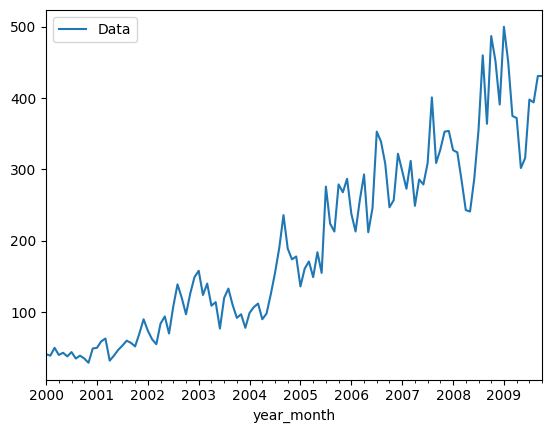

In [ ]:
# plot the series
crime.plot()

## Decomposing a time series
- we will use the statsmodel library which has 2 options in the tsa.seasonal package:
1. the seasonal_decompose function which returns an object that has 3 important attributes: seasonal, trend, and residual
2. the STL class which can remove the impact of outliers on the seasonal and trend components by setting the hyperparameter 'robust' to True

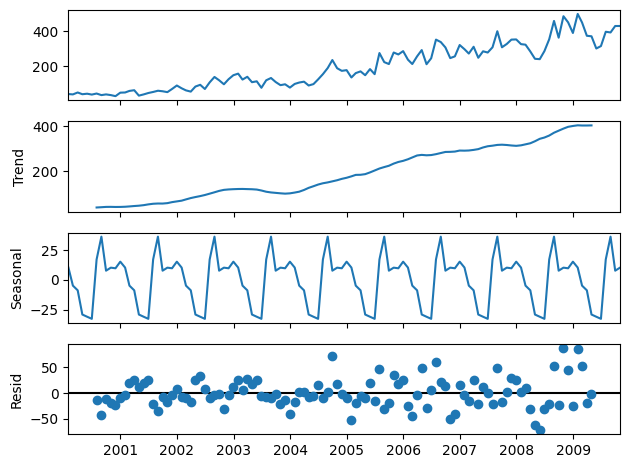

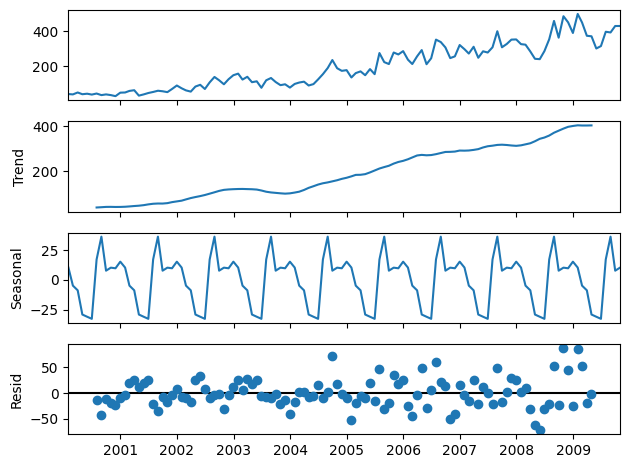

In [ ]:
# 1. the seasonal_decompose function
from statsmodels.tsa.seasonal import seasonal_decompose
crime_decomposed = seasonal_decompose(crime, model='additive')
# plot the 3 components along with the original series
crime_decomposed.plot()

<Axes: xlabel='year_month'>

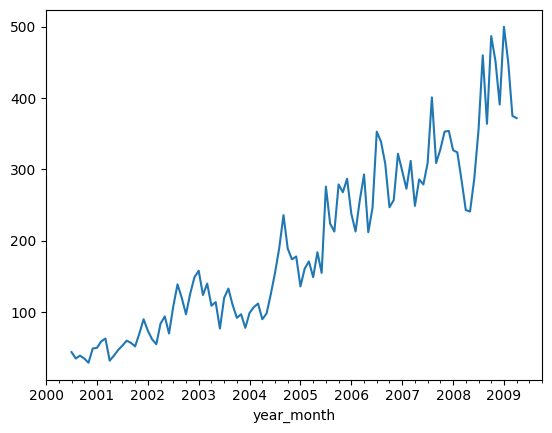

In [ ]:
# we can get the original series by adding the 3 components
(crime_decomposed.trend +
 crime_decomposed.seasonal +
 crime_decomposed.resid).plot()

## Moving Averages For Rainfall Dataset
- data is stationary
- we will just demo simple and weighted moving averages
- we will forecast values in the future using a simple exponential average model

In [ ]:
# skip the first row
rain = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2024-2025/DataPreparation/LondonRainfall.txt',
                   header=None, skiprows=1)
rain

,0
0,23.56 26.07 21.86 31.24 23.65 23.88
1,26.41 22.67 31.69 23.86 24.11 32.43
2,23.26 22.57 23.00 27.88 25.32 25.08
3,27.76 19.82 24.78 20.12 24.34 27.42
4,19.44 21.63 27.49 19.43 31.13 23.09
5,25.85 22.65 22.75 26.36 17.70 29.81
6,22.93 19.22 20.63 35.34 25.89 18.65
7,23.06 22.21 22.18 18.77 28.21 32.24
8,22.27 27.57 21.59 16.93 29.48 31.60
9,26.25 23.40 25.42 21.32 25.02 33.86


In [ ]:
# stack and flatten the values
values = rain.stack().values.flatten()
# join the values
values = ' '.join(list(values))
values

'23.56 26.07 21.86 31.24 23.65 23.88 26.41 22.67 31.69 23.86 24.11 32.43 23.26 22.57 23.00 27.88 25.32 25.08 27.76 19.82 24.78 20.12 24.34 27.42 19.44 21.63 27.49 19.43 31.13 23.09 25.85 22.65 22.75 26.36 17.70 29.81 22.93 19.22 20.63 35.34 25.89 18.65 23.06 22.21 22.18 18.77 28.21 32.24 22.27 27.57 21.59 16.93 29.48 31.60 26.25 23.40 25.42 21.32 25.02 33.86 22.67 18.82 28.44 26.16 28.17 34.08 33.82 30.28 27.92 27.14 24.40 20.35 26.64 27.01 19.21 27.74 23.85 21.23 28.15 22.61 19.80 27.94 21.47 23.52 22.86 17.69 22.54 23.28 22.17 20.84 38.10 20.65 22.97 24.26 23.01 23.67 26.75 25.36 24.79 27.88'

In [ ]:
# split on space
values = values.split(' ')
# create a dataframe and convert the values to float
rain = pd.DataFrame(values, columns=['Data'])
rain['Data'] = rain['Data'].astype(float)
# add a date time column and use it as index
rain['year'] = pd.date_range(start='1813', periods=len(rain), freq='Y')
rain = rain.set_index('year')
rain.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 1813-12-31 to 1912-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    100 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB


<Axes: xlabel='year'>

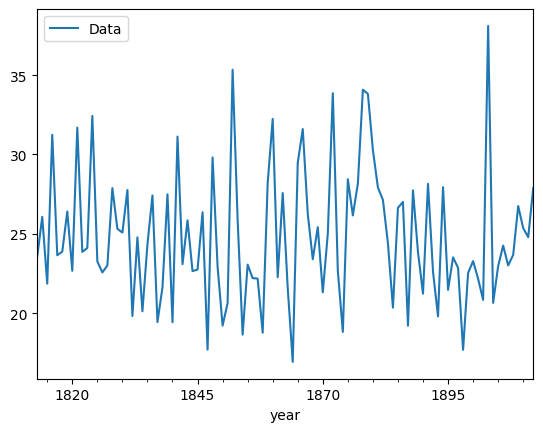

In [ ]:
rain.plot()

<Axes: title={'center': 'Original vs SMA3 vs SMA7'}, xlabel='year'>

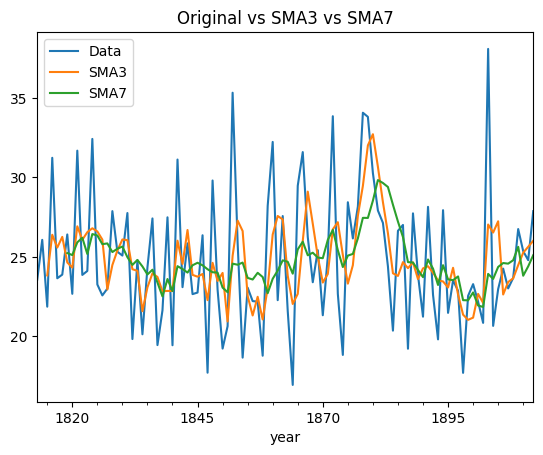

In [ ]:
# 1.a simple moving average with a window of size 3
rain['SMA3'] = rain['Data'].rolling(window=3).mean()
# 1.b simple moving average with a window of size 7
rain['SMA7'] = rain['Data'].rolling(window=7).mean()
rain.plot(title="Original vs SMA3 vs SMA7")

<Axes: title={'center': 'SMA3 vs WMA3'}, xlabel='year'>

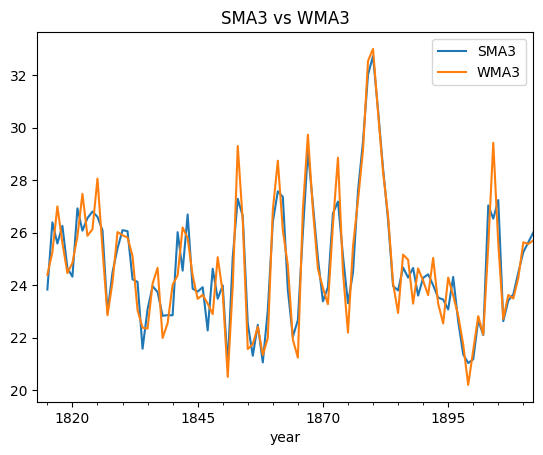

In [ ]:
# 2. weighted moving average with a window of 3
# we need to provide the list of weights first: they need to add up to 1
weights = np.array([ 0.25, 0.5, 0.25])
rain['WMA3'] = rain['Data'].rolling(window=3).apply(
    lambda x: np.sum(weights * x)
)
# plot the original series against the SMA5 and WMA5
rain[['SMA3', 'WMA3']].plot(title="SMA3 vs WMA3")

In [ ]:
# 3. simple exponential moving average; it has several hyperparameter that allows to specify the decay;
# we will use span to determine the size of the window
# Note: this can also be done using ewm from pandas:
# rain['EMA'] = rain['Data'].ewm(span=3).mean()
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
# train the model
sema_model = SimpleExpSmoothing(rain['Data']).fit(smoothing_level=None)
sema_model.params['smoothing_level']

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


0.024130015379608932

<Axes: title={'center': 'Original vs SEMA'}, xlabel='year'>

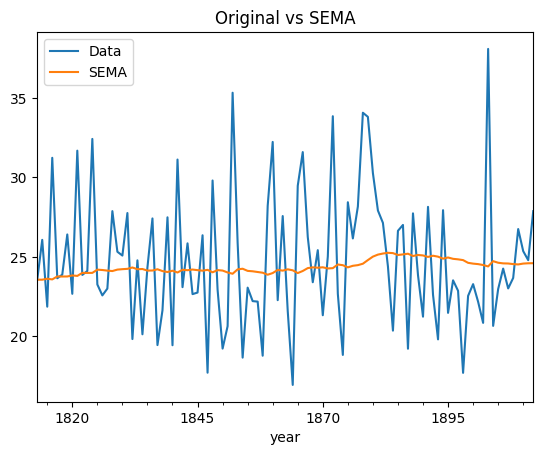

In [ ]:
# add the predictions to the dataframe
rain['SEMA'] = sema_model.fittedvalues
rain[['Data', 'SEMA']].plot(title="Original vs SEMA")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)


<Axes: title={'center': 'Original vs SEMA vs SEMA with alpha=0.3'}, xlabel='year'>

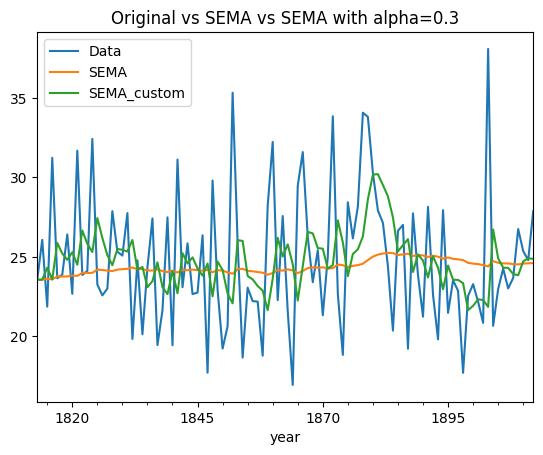

In [ ]:
sema_model_custom = SimpleExpSmoothing(rain['Data']).fit(smoothing_level=0.3, optimized=False)
rain['SEMA_custom'] = sema_model_custom.fittedvalues
rain[['Data', 'SEMA', 'SEMA_custom']].plot(title="Original vs SEMA vs SEMA with alpha=0.3")

In [ ]:
# predict future values and get confidence levels at 0.8
forecasts = ad.get_forecast_results(5, sema_model, rain['Data'], confidence=0.80)
forecasts

,Forecast,Lower Bound,Upper Bound
1913-12-31,24.678267,19.202525,30.154009
1914-12-31,24.678267,19.202525,30.154009
1915-12-31,24.678267,19.202525,30.154009
1916-12-31,24.678267,19.202525,30.154009
1917-12-31,24.678267,19.202525,30.154009


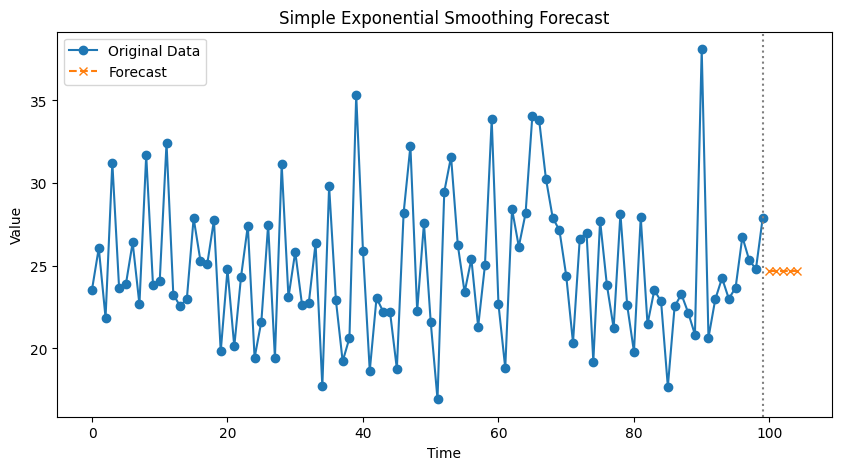

In [ ]:
# create x-axis ticks
original_time = np.arange(len(rain['Data']))
forecast_time = np.arange(len(rain['Data']), len(rain['Data']) + 5)
# plot the data
plt.figure(figsize=(10, 5))
plt.plot(original_time, rain['Data'], label="Original Data", marker='o')
plt.plot(forecast_time, forecasts['Forecast'], label="Forecast", marker='x', linestyle='dashed')
# mark the forecast start with a dotted line
plt.axvline(x=len(rain['Data'])-1, color='gray', linestyle='dotted')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simple Exponential Smoothing Forecast")
plt.legend()

In [ ]:
# predict future values and get confidence levels at 0.95
ad.get_forecast_results(5, sema_model, rain['Data'])

,Forecast,Lower Bound,Upper Bound
1913-12-31,24.678267,16.303843,33.052691
1914-12-31,24.678267,16.303843,33.052691
1915-12-31,24.678267,16.303843,33.052691
1916-12-31,24.678267,16.303843,33.052691
1917-12-31,24.678267,16.303843,33.052691


In [ ]:
# EXERCISE: experiment with different level smoothings, build new models, and see how forecasts change

## Moving Averages and Forecasting For Crime Dataset
- data is additive, so we can apply further exp. smoothing
- we will use the ExponentialSmoothing class from statsmodels api which calculates predictions as weighted sums of past observations where weights for past observations are decreasing exponentially.
  - we can specify the trend and seasonality types as 'additive' or 'multiplicative'.
  - we can also specify the number of periods in a complete seasonal cycle using the seasonal_periods parameter, e.g., 4 means quarterly, 7 means weekly, 12 means montly.
  - we can also specify the method for initialising the recursions using the initialization_method parameter, e.g., ‘estimated’ or ’heuristic’.
  - alpha, beta and gama are smoothing parameters for level, trend and seasonality, respectively, can be specified as arguments to the fit method using smoothing_level, smoothing_trend, and smoothing_seasonal, respectively.

0.5138517907857578 0.012433256659328562 0.00809814377425928


<Axes: title={'center': 'Original vs ES'}, xlabel='year_month'>

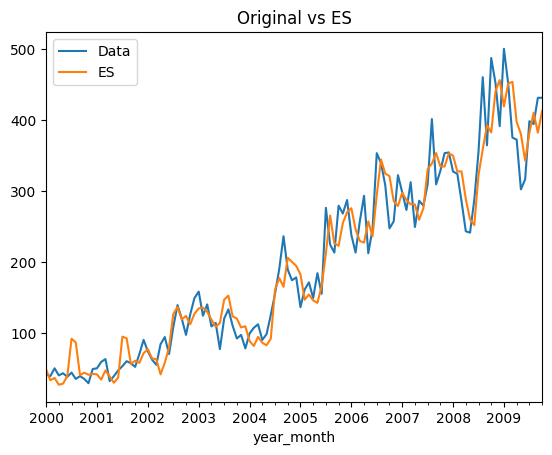

In [ ]:
# triple exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
es_model = ExponentialSmoothing(crime['Data'], trend='add', seasonal='add',
                                seasonal_periods=12, freq='M',
                                initialization_method='estimated')
es_model = es_model.fit()
print(es_model.params['smoothing_level'], es_model.params['smoothing_trend'],
      es_model.params['smoothing_seasonal'])
crime['ES'] = es_model.fittedvalues
crime.plot(title="Original vs ES")

In [ ]:
# predict future values and get confidence levels at 0.8
forecasts = ad.get_forecast_results(5, es_model, crime['Data'], confidence=0.80)
forecasts

,Forecast,Lower Bound,Upper Bound
2009-11-30,424.611573,381.569506,467.653639
2009-12-31,432.814625,389.772559,475.856692
2010-01-31,429.861080,386.819013,472.903147
2010-02-28,418.937064,375.894998,461.979131
2010-03-31,419.733753,376.691686,462.775820


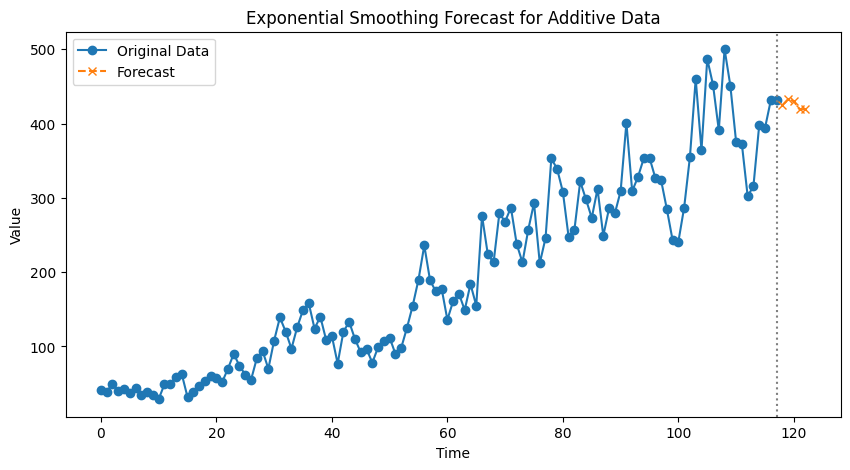

In [ ]:
# create x-axis ticks
original_time = np.arange(len(crime['Data']))
forecast_time = np.arange(len(crime['Data']), len(crime['Data']) + 5)
# plot the data
plt.figure(figsize=(10, 5))
plt.plot(original_time, crime['Data'], label="Original Data", marker='o')
plt.plot(forecast_time, forecasts['Forecast'], label="Forecast",
         marker='x', linestyle='dashed')
# mark the forecast start with a dotted line
plt.axvline(x=len(crime['Data'])-1, color='gray', linestyle='dotted')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Exponential Smoothing Forecast for Additive Data")
plt.legend()

## Training, Testing and Evaluating a TimeSeries Model

In [ ]:
# split the dataset into train and test portions
train_crime = crime['Data'][:111] # 111 rows for training
test_crime = crime['Data'][111:] # the remaining 7 rows for testing/forecasting comparisons
len(train_crime), len(test_crime)

(111, 7)

In [ ]:
# model with estimated smoothing
model1 = ExponentialSmoothing(
              train_crime, trend='additive',
              seasonal='additive', seasonal_periods=12, freq='M'
          ).fit()
# make 7 predictions into the future and compare with
predictions1 = model1.forecast(7).rename('estimated smoothing parameters predictions')
results = pd.concat([test_crime, predictions1], axis=1)
results

,Data,estimated smoothing parameters predictions
2009-04-30,372,401.782789
2009-05-31,302,404.270552
2009-06-30,316,406.210313
2009-07-31,398,457.365443
2009-08-31,394,479.333993
2009-09-30,431,454.628648
2009-10-31,431,459.090187


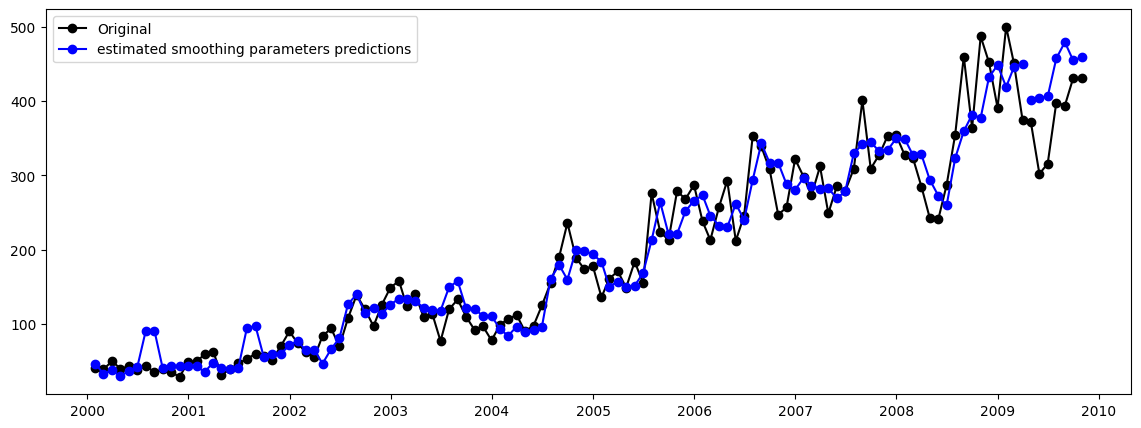

In [ ]:
plt.figure(figsize=(14, 5))
# plot the original series
plt.plot(train_crime, marker="o", color="black")
(line0, ) = plt.plot(test_crime, marker="o", color="black")
# plot the default smoothed data from 1st model and its predictions
plt.plot(model1.fittedvalues, marker="o", color="blue")
(line1, ) = plt.plot(predictions1, marker="o", color="blue")
plt.legend([line0, line1], ['Original', predictions1.name])

In [ ]:
# can compute MAE on the test data
from sklearn.metrics import mean_absolute_error
mae1 = mean_absolute_error(test_crime, predictions1)
rmse1 = math.sqrt(mean_squared_error(test_crime, predictions1))
print(f"MAE: {mae1:.4f}")
print(f"RMSE: {rmse1:.4f}")

MAE: 59.8117
RMSE: 67.2285


In [ ]:
# model with higher trend smoothing of 0.5
model2 = ExponentialSmoothing(
              train_crime, trend='additive',
              seasonal='additive', seasonal_periods=12, freq='M'
        ).fit(smoothing_trend=0.5)
## make 7 predictions into the future
predictions2 = model2.forecast(7).rename('beta = 0.5 predictions')
results = pd.concat([results, predictions2], axis=1)
results

,Data,estimated smoothing parameters predictions,beta = 0.5 predictions
2009-04-30,372,401.782789,395.607168
2009-05-31,302,404.270552,380.210815
2009-06-30,316,406.210313,364.378520
2009-07-31,398,457.365443,397.510262
2009-08-31,394,479.333993,403.661696
2009-09-30,431,454.628648,361.647391
2009-10-31,431,459.090187,350.646208


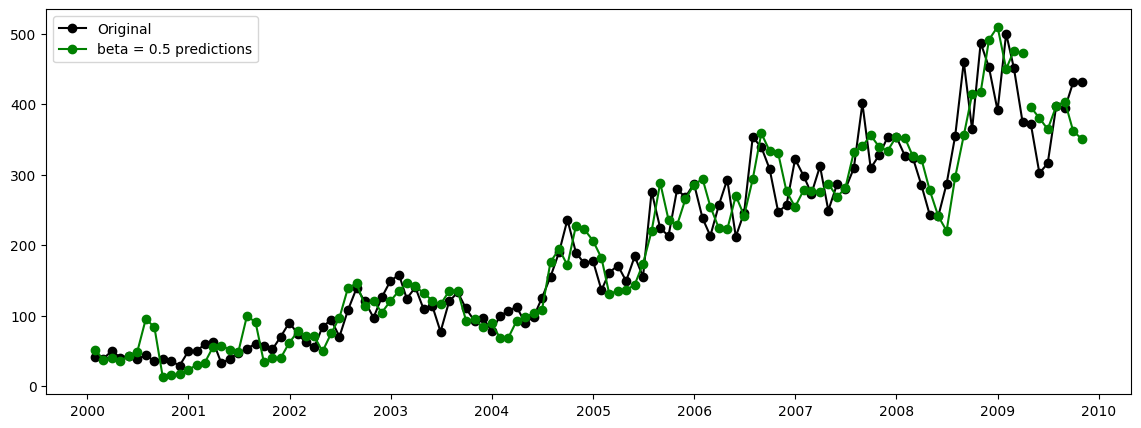

In [ ]:
plt.figure(figsize=(14, 5))
# plot the original series
plt.plot(train_crime, marker="o", color="black")
(line0, ) = plt.plot(test_crime, marker="o", color="black")
# plot the smoothed data from 2nd model and its predictions
plt.plot(model2.fittedvalues, marker="o", color="green")
(line2, ) = plt.plot(predictions2, marker="o", color="green")
plt.legend([line0, line2], ['Original', predictions2.name])

In [ ]:
# can compute MAE on the test
mae2 = mean_absolute_error(test_crime, predictions2)
rmse2 = math.sqrt(mean_squared_error(test_crime, predictions2))
print(f"MAE: {mae2:.4f}")
print(f"RMSE: {rmse2:.4f}")

MAE: 44.2935
RMSE: 53.9508


In [ ]:
# EXERCISE: experiment with different smoothings, build new models, and see how forecasts change

## Visualise Autocorrelation
- again, we will use the statsmodel api

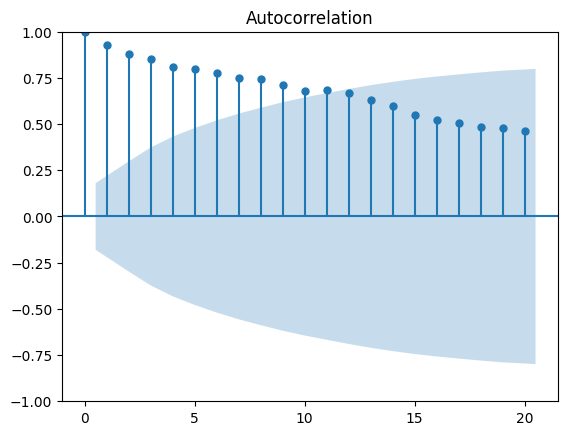

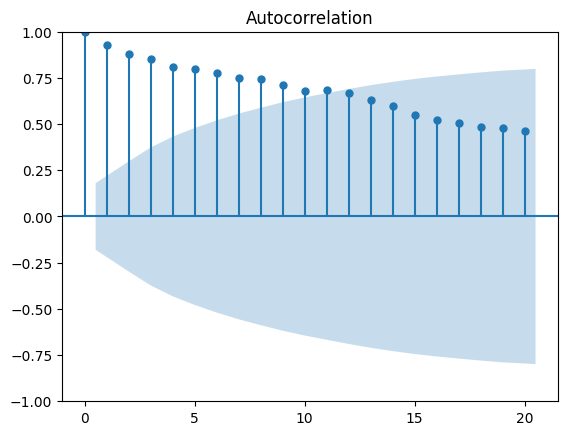

In [ ]:
# autocorrelation with 20 lags
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(crime.Data, lags=20)

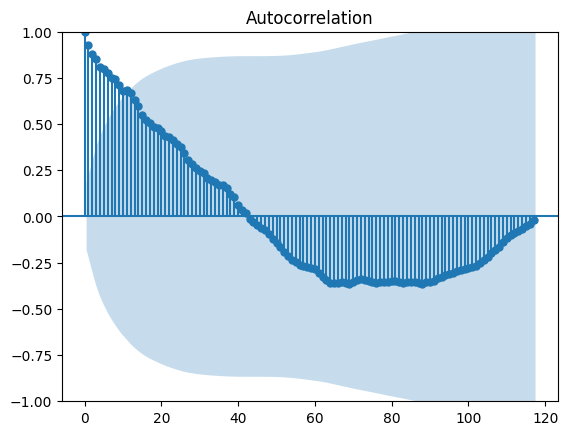

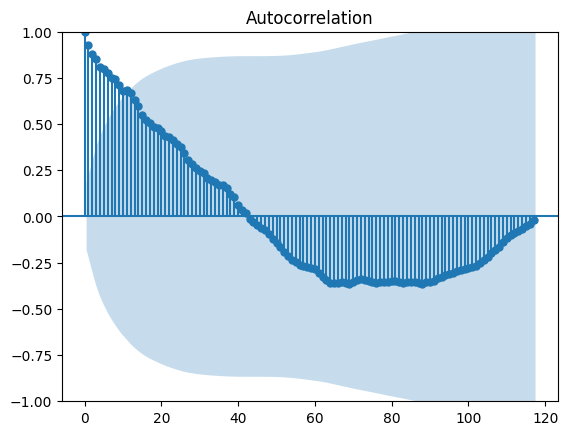

In [ ]:
# autocorrelation with 117 lags
plot_acf(crime.Data, lags=117)

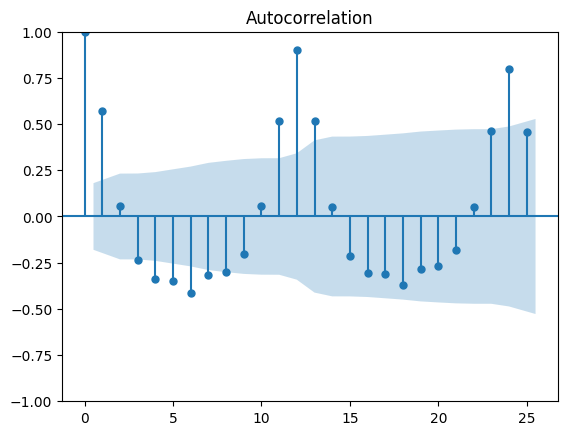

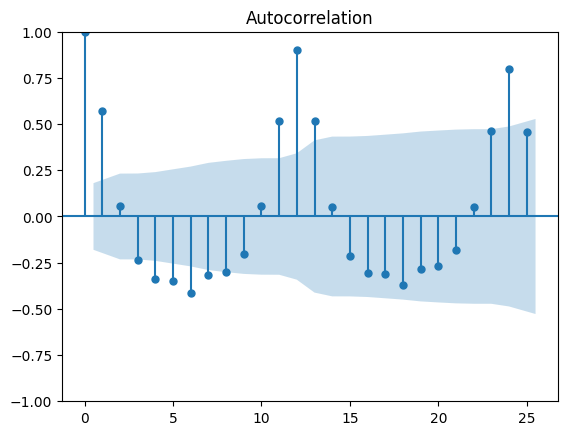

In [ ]:
# we can plot the autocorrelation on the seasonal component
plot_acf(crime_decomposed.seasonal, lags=25)

## ARMA and ARIMA
- we can use the general purpose class ARIMA from statsmodel api as it allows specialised cases, including:
  - autoregressive models: AR(p)
  - moving averages models: MA(q)
  - mixed autoregressive moving averages models: ARMA(p, q)
  - integration models: ARIMA(p, d, q)
  - seasonal models: SARIMA(p, d, q, s)
  - regression with errors that follows one of the above
1. to build an ARMA model with the ARIMA class, in the tuple of the order hyperparameter, we need to specify the second value for the differencing parameter to be equal to 0.
2. to build an ARIMA model with the ARIMA class, in the tuple of the order hyperparameter, we need to specify the second value for the differencing parameter to be greater than 0, e.g. d=1 (first order differencing).

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# 1. ARMA
# Train the model on the train portion and specify d=0 (the second value of the order tuple)
# the first and third values - p and q - must be greater than 0, e.g., 2 and 3
arma_model = ARIMA(train_crime, order=(2, 0, 3)).fit()
arma_model.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   Data   No. Observations:                  111
Model:                 ARIMA(2, 0, 3)   Log Likelihood                -561.922
Date:                Fri, 28 Feb 2025   AIC                           1137.844
Time:                        12:01:43   BIC                           1156.810
Sample:                    01-31-2000   HQIC                          1145.538
                         - 03-31-2009                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        184.8731    153.467      1.205      0.228    -115.916     485.662
ar.L1          0.5230      0.505      1.035      0.301      -0.468       1.514
ar.L2          0.4610      0.491      0.939      0.348      -0.502       1.424
ma.L1          0.1501      0.501      0.300      0.764      -0.831       1.131
ma.L2         -0.3318      0.143     -2.324      0.020      -0.612      -0.052
ma.L3          0.0672      0.129      0.519      0.603      -0.186       0.321
sigma2      1420.8185    155.170      9.157      0.000    1116.691    1724.946
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                46.35
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):              11.26   Skew:                             1.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# generate 7 predictions in the future
arma_preds = arma_model.predict(start=111, end=117)
# compare them to the actual 7 values from the test portion ans get the RMSE
arma_rmse = math.sqrt(mean_squared_error(arma_preds, test_crime))
arma_mae = mean_absolute_error(arma_preds, test_crime)
print(arma_preds)
print("RMSE = %.2f" % arma_rmse)
print(f"MAE: {arma_mae:.4f}")

2009-04-30    405.995778
2009-05-31    409.351109
2009-06-30    399.752242
2009-07-31    400.733670
2009-08-31    396.821993
2009-09-30    395.228659
2009-10-31    392.592134
Freq: ME, Name: predicted_mean, dtype: float64
RMSE = 56.65
MAE: 43.5477


In [ ]:
# 2. ARIMA
# Train a 1st order differencing model on the train portion and specify
# p and q as 1 and 2, respectively, based on previous results
arima1_model = ARIMA(train_crime, order=(1, 1, 2)).fit()
print(arima1_model.summary())
## generate 7 predictions in the future
arima1_preds = arima1_model.predict(start=111, end=117)
## compare them to the actual 7 values from the test portion ans get the RMSE
arima1_rmse = math.sqrt(mean_squared_error(arima1_preds, test_crime))
arima1_mae = mean_absolute_error(arima1_preds, test_crime)
print(arima1_preds)
print(f"MAE: {arima1_mae:.4f}")
print("RMSE = %.2f" % arima1_rmse)

                               SARIMAX Results                                
Dep. Variable:                   Data   No. Observations:                  111
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -555.659
Date:                Fri, 28 Feb 2025   AIC                           1119.318
Time:                        12:02:05   BIC                           1130.120
Sample:                    01-31-2000   HQIC                          1123.699
                         - 03-31-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5470      0.222     -2.464      0.014      -0.982      -0.112
ma.L1          0.2211      0.225      0.980      0.327      -0.221       0.663
ma.L2         -0.3922      0.094     -4.194      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
## we can try improving the model by adding second and third rounds of differencing
arima2_model = ARIMA(train_crime, order=(1, 2, 2)).fit()
print(arima2_model.summary())
## generate 7 predictions in the future
arima2_preds = arima2_model.predict(start=111, end=117)
## compare them to the actual 7 values from the test portion ans get the RMSE
arima2_rmse = math.sqrt(mean_squared_error(arima2_preds, test_crime))
arima2_mae = mean_absolute_error(arima2_preds, test_crime)
print(arima2_preds)
print("RMSE = %.2f" % arima2_rmse)
print(f"MAE: {arima2_mae:.4f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Data   No. Observations:                  111
Model:                 ARIMA(1, 2, 2)   Log Likelihood                -561.890
Date:                Fri, 28 Feb 2025   AIC                           1131.779
Time:                        12:02:14   BIC                           1142.545
Sample:                    01-31-2000   HQIC                          1136.145
                         - 03-31-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9854      0.075    -13.178      0.000      -1.132      -0.839
ma.L1         -0.0002      1.033     -0.000      1.000      -2.025       2.024
ma.L2         -0.9979      0.957     -1.043      0.2

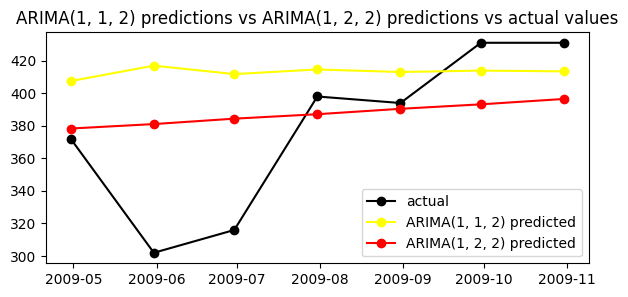

In [ ]:
# plot both sets of predictions against the actual values
fig = plt.figure(figsize=(7, 3))
plt.plot(test_crime, label='actual', color='black', marker='o')
plt.plot(arima1_preds, label='ARIMA(1, 1, 2) predicted', color='yellow', marker='o')
plt.plot(arima2_preds, label='ARIMA(1, 2, 2) predicted', color='red', marker='o')
plt.title('ARIMA(1, 1, 2) predictions vs ARIMA(1, 2, 2) predictions vs actual values')
plt.legend()

## Using Regression Models
- any time-indexed dataset can be fed to a regression algorithm and evaluated using crossvalidation
  - in this context, the regular attributes can be those from moving averages etc., or any other attribute that was part of the dataset originally, while the target variable should be the original series.
  - however, because the dataset is time-ordered, we cannot use the typical cross-validation fucntion since that will randomise the data; instead, we need to use the time-sensitive crossvalidation class TimeSeriesSplit

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
# because we have a small dataset, create 3 folds only (default is 5)
ts_cv = TimeSeriesSplit(n_splits=3, max_train_size=111, test_size=7)

In [ ]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118 entries, 2000-01-31 to 2009-10-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    118 non-null    int64  
 1   ES      118 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.8 KB


In [ ]:
# add the differenced version of the series
crime['Diff1'] = crime['Data'].diff()
crime.head(7)

,Data,ES,Diff1
year_month,,,
2000-01-31,41,48.403831,NaN
2000-02-29,39,33.110543,-2.0
2000-03-31,50,36.415744,11.0
2000-04-30,40,26.773370,-10.0
2000-05-31,43,28.450196,3.0
2000-06-30,38,38.938724,-5.0
2000-07-31,44,91.598288,6.0


In [ ]:
from sklearn.impute import SimpleImputer
X = crime[crime.columns.difference(['Data'])]
# impute missing values
imputer = SimpleImputer().fit(X)
X[X.columns] = imputer.transform(X)
y = crime['Data']

In [ ]:
# we can then use the cross_validate function to which we pass the regressor,
# the X and y, the timeseries splitter object, as well as the metrics used
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsRegressor
scores = cross_validate(KNeighborsRegressor(), X, y, cv=ts_cv,
            scoring=["neg_mean_absolute_error","neg_root_mean_squared_error"])
mae_scores = scores["test_neg_mean_absolute_error"]
rmse_scores = scores["test_neg_root_mean_squared_error"]
print(
    f"Mean Absolute Error:{mae_scores.mean():.3f} +/- {mae_scores.std():.3f}\n"
    f"Root Mean Squared Error: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}"
)

Mean Absolute Error:-52.457 +/- 31.903
Root Mean Squared Error: -63.494 +/- 27.375


In [ ]:
# EXERCISE: make use of pipelines and crossvalidation to reduce the risk of data leakage